In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
import decoupler as dc

In [4]:
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()
# gene_trends = palantir.presults.compute_gene_trends(
#     adata_raw,
#     expression_key="MAGIC_imputed_data",
# )

In [ ]:
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()


# Resume

In [5]:
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()

ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir


AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [6]:
impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

In [7]:
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload


In [8]:
#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    adata_raw,
    expression_key='MAGIC_imputed_data',  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

Bas/MC prog


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[2025-06-11 23:49:24,712] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (10,626) and rank = 1.0.
[2025-06-11 23:49:24,713] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-11 23:49:26,062] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono/DC prog
[2025-06-11 23:49:30,061] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (14,157) and rank = 1.0.
[2025-06-11 23:49:30,062] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-11 23:49:30,925] [INFO    ] Sigma interpreted as element-wise standard deviation.
Neu
[2025-06-11 23:49:37,762] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (23,442) and rank = 1.0.
[2025-06-11 23:49:37,763] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-11 23:49:39,130] [INFO    ] Sigma interpreted as element-wise standard deviation.
Ly
[2025-06-11 23:49:44,527] [INFO    ] Using sparse Gaussian Process since n_landm

# compare with inferred parameters

In [19]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = adata_raw[adata_raw.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime
    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, 21)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=20,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.39 0.67 0.35 0.3  0.44 0.25 0.53 0.48 0.58 0.62 0.21 0.81 0.76 0.9
 0.07 0.16 0.71 0.85 0.12 0.02]
[0.34 0.37 0.26 0.28 0.42 0.39 0.31 0.45 0.47 0.23 0.53 0.5  0.07 0.18
 0.15 0.2  0.12 0.09 0.04 0.01]
[0.38 0.32 0.45 0.55 0.25 0.58 0.42 0.28 0.62 0.35 0.52 0.48 0.65 0.22
 0.08 0.18 0.15 0.12 0.05 0.02]


In [10]:
# prior knowledge of TFs involved in hematopoiesis
blood_lineage_tfs = {
    "HSC": ["Gata2", "Runx1", "Tal1", "Lmo2", "Meis1", "Hhex", "Erg"],
    "Erythroid": ["Gata1", "Klf1", "Tal1", "Ldb1", "Hba-a1", "Hba-x", "Bpgm", "Gypa"],
    "Megakaryocyte": ["Gata1", "Gfi1b", "Fli1", "Runx1"],
    "Myeloid_Granulocyte": ["Cebpa", "Spi1", "Gfi1", "Cebpe"],
    "Myeloid_Monocyte": ["Spi1", "Irf8", "Cebpb", "Cd68"],
    "Lymphoid_T": ["Bcl11b", "Gata3", "Tcf7", "Notch1"],
    "Lymphoid_B": ["Ebf1", "Pax5", "Foxo1"],
    "Lymphoid_NK": ["Nfil3", "Eomes", "Id2"],
    "Dendritic_Cell": ["Irf8", "Zbtb46", "Batf3"],
    "Macrophage": ["Spi1", "Irf5", "Mafb"]
}

In [11]:
from importlib import reload
reload(pl)

<module 'PINN.plotting_fns' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/__init__.py'>

### Neu lineage

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Myeloid_Granulocyte'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Neu'][0],
                    para_name = "\nPINN v Day7")

ax.set_title("Neu lineage Day7 diff rate along Myeloid_Granulocyte Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Neu'][0],
                    para_name = "\nPINN g Day7")

ax.set_title("Neu lineage Day7 growth rate along Myeloid_Granulocyte Markers")

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Myeloid_Granulocyte'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Neu'][-2],
                    para_name = "\nPINN v Day161")

ax.set_title("Neu lineage Day161 diff rate along Myeloid_Granulocyte Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Neu'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Neu lineage Day161 growth rate along Myeloid_Granulocyte Markers")

### Ery lineage

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Erythroid'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Ery'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Ery'][-2],
                    para_name = "\nPINN v Day161")
ax.set_title("Ery lineage Day161 diff rate along Erythroid Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Ery'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Ery'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Ery lineage Day161 growth rate along Erythroid Markers")

### Meg lineage

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Megakaryocyte'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][-2],
                    para_name = "\nPINN v Day161")
ax.set_title("Meg lineage Day161 diff rate along MEP Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Meg lineage Day161 growth rate along MEP Markers")

In [63]:
Meg_markers = ['Itga2b' ]
megakaryocyte_genes = {
    "early": [
        "Itga2b",  # CD41 (αIIb integrin) marks earliest lineage commitment [1][3][8]
        "Mpl",      # Thrombopoietin receptor (c-Mpl) [1][4]
        "Cd9",      # Surface marker for MK progenitors [8]
        "Vwf",      # Von Willebrand factor (megakaryocyte marker) [4][12]
        "Gata1",    # Initiates transcriptional cascade [1][4]
        "Zfpm1",    # FOG1 cofactor for GATA1 in early commitment [1][6]
        "Gabpa",    # Regulates Itga2b/Mpl promoters [1][7]
        "Runx1"     # Represses erythroid genes, promotes MK programs [4][8]
    ],
    "late": [
        "Gp1ba",    # CD42b (GPIbα) platelet adhesion receptor [1][9][11]
        "Gp9",      # Component of GPIb-IX-V complex [10]
        "Pf4",      # Platelet factor 4 (hemostatic factor) [1][11][12]
        "Tubb1",    # β1-tubulin for proplatelet formation [1][3][12]
        "Cd42d",    # Mature MK marker (GPV component) [11][13][16]
        "Fli1",     # Regulates late genes (Gp9/Gp1ba/Pf4) [1][8][14]
        "Nfe2"      # Essential for terminal maturation [1][4][15]
    ]
}

In [ ]:
overlap_genes = np.intersect1d(megakaryocyte_genes['late'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][-2],
                    para_name = "\nPINN v Day161")
ax.set_title("Meg lineage Day161 diff rate along late Meg Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Meg lineage Day161 growth rate along late Meg Markers")

In [ ]:
overlap_genes = np.intersect1d(megakaryocyte_genes['early'], adata_raw.var_names)


fig, axs = plt.subplots(2,2, figsize=(16, 10), frameon=False, sharex=True)
axs = axs.flatten()
pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][0],
                    para_name = "\nPINN v Day7",
                    ax = axs[0])
                    
axs[0].set_title("Meg lineage Day7 growth rate along early Meg Markers")
axs[0].legend(ncol=4, loc='upper center', bbox_to_anchor=(0.3, 1.5), fontsize=10)

pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][0],
                    para_name = "\nPINN v Day7",
                    ax = axs[1]
                    )
axs[1].set_title("Meg lineage Day7 diff rate along early Meg Markers")
axs[1].legend([], frameon=False)


pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][-2],
                    para_name = "\nPINN g Day161",
                    ax = axs[2]
                    )
axs[2].set_title("Meg lineage Day161 growth rate along early Meg Markers")
axs[2].legend([], frameon=False)

pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][-2],
                    para_name = "\nPINN v Day161",
                    ax = axs[3]
                    )
axs[3].set_title("Meg lineage Day161 diff rate along early Meg Markers")
axs[3].legend([], frameon=False)

In [ ]:
overlap_genes = np.intersect1d(megakaryocyte_genes['late'], adata_raw.var_names)


fig, axs = plt.subplots(2,2, figsize=(16, 10), frameon=False, sharex=True)
axs = axs.flatten()
pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][0],
                    para_name = "\nPINN v Day7",
                    ax = axs[0])
                    
axs[0].set_title("Meg lineage Day7 growth rate along late Meg Markers")
axs[0].legend(ncol=4, loc='upper center', bbox_to_anchor=(0.3, 1.5), fontsize=10)

pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][0],
                    para_name = "\nPINN v Day7",
                    ax = axs[1]
                    )
axs[1].set_title("Meg lineage Day7 diff rate along late Meg Markers")
axs[1].legend([], frameon=False)


pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][-2],
                    para_name = "\nPINN g Day161",
                    ax = axs[2]
                    )
axs[2].set_title("Meg lineage Day161 growth rate along late Meg Markers")
axs[2].legend([], frameon=False)

pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][-2],
                    para_name = "\nPINN v Day161",
                    ax = axs[3]
                    )
axs[3].set_title("Meg lineage Day161 diff rate along late Meg Markers")
axs[3].legend([], frameon=False)

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Megakaryocyte'], adata_raw.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][-2],
                    para_name = "\nPINN v Day161")
ax.set_title("Meg lineage Day161 diff rate along MEP Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Meg lineage Day161 growth rate along MEP Markers")



# derivitive correlation

In [12]:
# Building on your existing notebook
import numpy as np
import scanpy as sc
from scipy import stats
import matplotlib.pyplot as plt

# Search for correlate genes

In [13]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.interpolate import interp1d

def subsample_gene_trends(gene_trends, gt_x, target_x):
    """
    Interpolates gene trends to match the target pseudotime bins.
    gene_trends: DataFrame (genes x pseudotime bins)
    gt_x: array-like, original pseudotime positions of gene trends
    target_x: array-like, target pseudotime positions (e.g., param_curve bins)
    Returns: DataFrame (genes x target pseudotime bins)
    """
    interpolated = []
    TF_index = []
    for gene in gene_trends.index:
        # # skip genes not in the mouse TF list
        # if gene not in mm_tf_found:
        #     continue
        # Interpolate the gene trend to the target pseudotime bins
        f = interp1d(gt_x, gene_trends.loc[gene], kind='linear', fill_value='extrapolate')
        interpolated.append(f(target_x))
        TF_index.append(gene)
    return pd.DataFrame(interpolated, index=TF_index, columns=target_x)


def correlate_gene_trends(gene_trends, param_curve):
    """
    gene_trends: DataFrame (genes x pseudotime bins)
    param_curve: 1D array (same length as pseudotime bins)
    Returns: DataFrame with correlation and p-value for each gene
    """
    results = []
    for gene in gene_trends.index:
        y = gene_trends.loc[gene].values
        corr, pval = stats.pearsonr(y, param_curve)
        results.append({'gene': gene, 'corr': corr, 'pval': pval})
    return pd.DataFrame(results).set_index('gene')


def significant_genes(corr_df, alpha=0.05):
    """
    Apply FDR correction to p-values to identify significantly correlated genes.
    """
    corr_df['fdr'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
    return corr_df[corr_df['fdr'] < alpha].sort_values('corr', ascending=False)


def cluster_gene_trends(gene_trends, n_clusters=3):
    """
    Cluster the significantly correlated genes by their trend curves (e.g., using hierarchical clustering or k-means).
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(gene_trends)
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X)
    return labels

def plot_param_and_clusters(gene_trends, param_curve, cluster_labels, pseudotime_bins):
    
    clusters = np.unique(cluster_labels)
    fig=plt.figure(figsize=(10,4))
    ax1 = fig.gca()
    # Plot parameter curve
    
    # Plot mean ± std for each cluster
    for c in clusters:
        idx = cluster_labels == c
        mean_trend = gene_trends[idx].mean(axis=0)
        std_trend = gene_trends[idx].std(axis=0)
        ax1.plot(pseudotime_bins, mean_trend, label=f'Cluster {c+1}')
        plt.fill_between(pseudotime_bins, mean_trend-std_trend, mean_trend+std_trend, alpha=0.2)

    ax2 = ax1.twinx()
    ax2.plot(pseudotime_bins, param_curve, color='black',linestyle='--',  lw=2, label='Parameter')


    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.15, 1), loc='upper left')


    plt.xlabel('Scaled Pseudotime')
    ax1.set_ylabel('Expression ')
    # ax2.set_ylabel('\nParameter Value')
    plt.tight_layout()
    plt.show()


# derivatives

In [ ]:
# 1. Get parameters and pseudotime from your data
timepoint_i = 0
lineage = 'Neu'

day = ad_palantir.uns['pop']['t'][timepoint_i]


pseudotime = adata_raw.obs['palantir_pseudotime'].values
drift = v_project[lineage][timepoint_i]  # Assuming first dimension is the drift
growth = g_project[lineage][timepoint_i]       # Assuming first dimension is growth
x  = np.array(x_project[lineage])    

# 2. Calculate derivatives (similar to R's diff_drift function)
def calculate_derivative(x, y):
    """Calculate derivative using central differences"""
    dy = np.zeros_like(y)
    dy[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
    dy[0] = dy[1]
    dy[-1] = dy[-2]
    return dy

drift_deriv = calculate_derivative(x, drift)

# 3. subsample the gene trend to 99 points
gene_trends_lin = adata_lin[lineage].varm[f'gene_trends_{lineage}']
gt_x = gene_trends_lin.columns.astype(float)  # genetrend x Convert column names to float for plotting
target_x = np.linspace(0, gt_x.max(), 99)  # target x (99, ) Assuming this is the target pseudotime bins
gene_trend_sup = subsample_gene_trends(gene_trends_lin, gt_x, target_x)

# # 4. Calculate gene-parameter correlations
correlations = np.array([stats.pearsonr(gene_trend_sup.iloc[i,:].values, drift_deriv)[0] 
                         for i in range(gene_trend_sup.shape[0])])
correlations = np.where(np.isnan(correlations), 0, correlations)

# 4. Get top correlated genes (similar to R's analysis)
top_genes_idx = np.argsort(correlations)[-10:]
top_genes = adata_raw.var_names[top_genes_idx]



In [54]:

# 4. Get top correlated genes (similar to R's analysis)
top_genes_idx = np.argsort(correlations)[-10:]
top_genes = adata_raw.var_names[top_genes_idx]

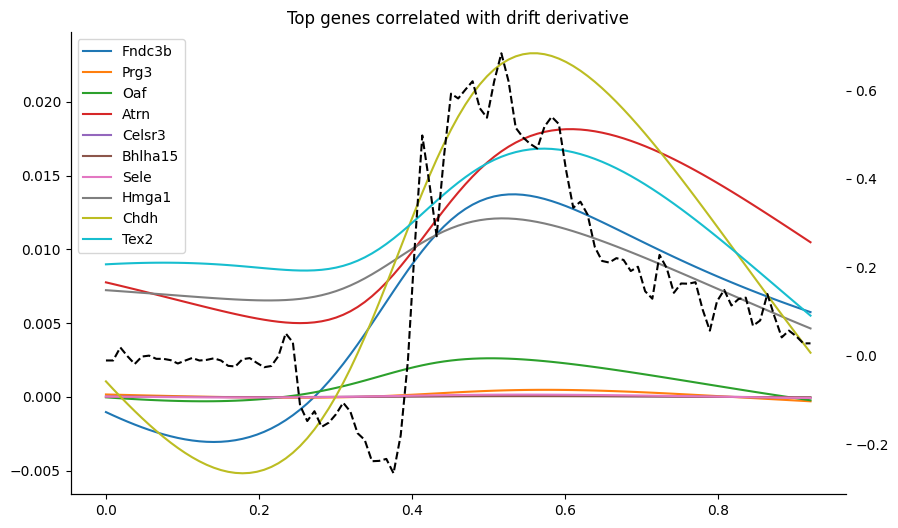

In [55]:
# 5. Plot results (building on your existing plotting functions)
fig, ax = plt.subplots(figsize=(10,6))
for gene in top_genes:
    ax.plot(target_x, gene_trend_sup.loc[gene].values, 
            label=gene)

ax2 = ax.twinx()
ax2.plot(target_x, drift_deriv*10, 'k--', label='Drift derivative (scaled)')
ax.legend()
ax.set_title('Top genes correlated with drift derivative')
plt.show()

In [53]:

# print(target_x)

# expr - param correlation

In [57]:
def corr_analysis(lineage, param_curve):
    """
    Perform subsampling, correlation, and clustering for a given lineage.
    lineage: str, e.g., 'Neu', 'Meg', 'Ery'
    param_curve: 1D array of parameter values (e.g., v or g)
    """
   
    gene_trends_neu = adata_lin[lineage].varm[f'gene_trends_{lineage}']
    sub_gene_trend_TFs = subsample_gene_trends(gene_trends_neu, gt_x, target_x)

    # correlate gene trends with the parameter curve
    corr_df = correlate_gene_trends(sub_gene_trend_TFs, param_curve)

    return corr_df.dropna()


def pick_gt_and_corr_analysis(lineage, param_curve, n_clusters=4,corr_thres=0.9, alpha=1, plotting=True):
    """
    Perform subsampling, correlation, and clustering for a given lineage.
    lineage: str, e.g., 'Neu', 'Meg', 'Ery'
    param_curve: 1D array of parameter values (e.g., v or g)
    n_clusters: int, number of clusters for hierarchical clustering
    """
   
    gene_trends_neu = adata_lin[lineage].varm[f'gene_trends_{lineage}']
    sub_gene_trend_TFs = subsample_gene_trends(gene_trends_neu, gt_x, target_x)

    # correlate gene trends with the parameter curve
    corr_df = correlate_gene_trends(sub_gene_trend_TFs, param_curve).dropna()
    sig_genes = significant_genes(corr_df, alpha=alpha)
    sig_genes = sig_genes[sig_genes['corr'] > corr_thres]  # Filter for strong correlations
    sig_trends = sub_gene_trend_TFs.loc[sig_genes.index]

    # cluster
    labels = cluster_gene_trends(sig_trends.values, n_clusters=n_clusters)
    sig_genes['cluster'] = labels
    print(f"Number of significant genes: {len(sig_genes)}")
    sig_genes.head()

    # plot
    if plotting:
        sig_genes.plot(kind='hist', y='corr', figsize=(10, 4), bins=40, title='Significant Genes Correlation with Growth Rate')
        plot_param_and_clusters(sig_trends.values, param_curve, labels, target_x)
    return sig_genes

In [60]:
def corr_test_and_plot_clusters(lineage, param_curve, param_name, n_clusters=4, corr_thres=0.9, alpha=1, dpi=80):
    """
    Perform correlation test and plot clusters for a given lineage.
    lineage: str, e.g., 'Neu', 'Meg', 'Ery'
    param_curve: 1D array of parameter values (e.g., v or g)
    param_name: str, name of the parameter and Day (e.g., 'v', 'g')
    n_clusters: int, number of clusters for hierarchical clustering
    """
    
    sig_genes = pick_gt_and_corr_analysis(lineage, param_curve, n_clusters=4, corr_thres=corr_thres, alpha=alpha, plotting=False)

    figall, axs = plt.subplots(n_clusters, 1, figsize=(6, 3*n_clusters), dpi=dpi,
                                sharex=True, gridspec_kw={'hspace': 0.35})
    axs = axs.flatten()

    for group in range(n_clusters):
        genes = sig_genes[sig_genes['cluster'] == group].index
        fig, ax, ax2 = pl.plot_gene_trends(adata_lin[lineage],
                        gene_trend_key = f'gene_trends_{lineage}', 
                        gene_list= genes,
                        PINN_params = param_curve,
                        para_name = param_name,
                        ax = axs[group]
                        )
        ax2.set_yticks([])
        axs[group].set_title(f"TF cluster {group}")

    figall.suptitle(f"{lineage} lineage {param_name} rate along TF clusters")

In [48]:
corr_df = corr_analysis("Meg", v_project['Meg'][0]).dropna()
sig_genes = significant_genes(corr_df, alpha=1)

/tmp/ipykernel_512331/1263785860.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.pearsonr(y, param_curve)


/tmp/ipykernel_512331/1263785860.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.pearsonr(y, param_curve)


Number of significant genes: 69


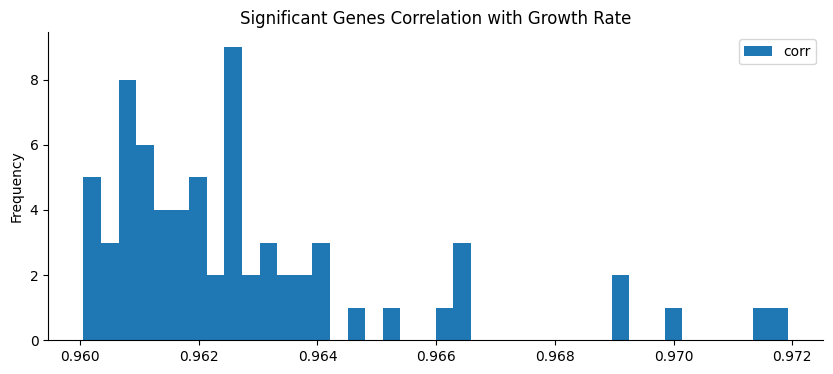

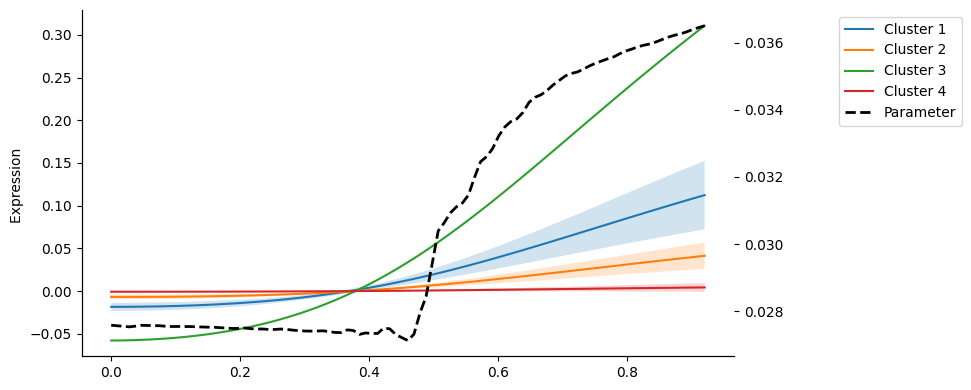

In [56]:
sig_genes = pick_gt_and_corr_analysis("Meg", v_project['Meg'][0], n_clusters=4, corr_thres=0.96, alpha=1e-35)

In [ ]:
sig_genes = corr_test_and_plot_clusters("Meg", v_project['Meg'][0], "\nPINN v Day7", n_clusters=4, corr_thres=0.96, alpha=1e-45)

In [ ]:
corr_test_and_plot_clusters("Meg", v_project['Meg'][-2], "\nPINN v Day161", n_clusters=4, corr_thres=0.95)

In [ ]:
corr_test_and_plot_clusters("Meg", g_project['Meg'][-2], "\nPINN g Day7", n_clusters=4, corr_thres=0.95)

In [ ]:
corr_test_and_plot_clusters("Meg", g_project['Meg'][-2], "\nPINN g Day161", n_clusters=4, corr_thres=0.95)